In [1]:
import numpy as np
import matplotlib.pyplot as plt
import qcodes as qc
import pandas as pd
from qcodes.dataset import initialise_database, initialise_or_create_database_at, load_or_create_experiment, plot_dataset
from qcodes.dataset.experiment_container import experiments

from qcodes.dataset.experiment_container import load_experiment_by_name, load_experiment
from qcodes.dataset.data_set import load_by_id


from pathlib import Path
from scipy import stats
from scipy.optimize import curve_fit

In [2]:
initialise_or_create_database_at(Path.cwd() / '20251016_4K.db')

In [3]:
def load_specfic_dataset(id_number):
    dataset = load_by_id(id_number)
    dataset_pd = dataset.to_pandas_dataframe()
    df_reset = dataset_pd.reset_index()
    return df_reset

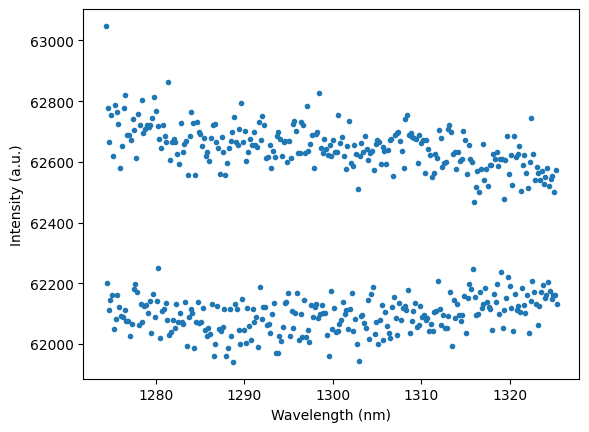

In [4]:
df_reference = load_specfic_dataset(11)
df_reference.head()
plt.plot(df_reference['Shamrock_calibration'], df_reference['Andor_spectrum'], ".")
plt.xlabel("Wavelength (nm)")
plt.ylabel("Intensity (a.u.)")
plt.show()

In [5]:
# load the background
df_background = load_specfic_dataset(1)

In [6]:
# subtract background from reference
df_reference["Andor_spectrum_bg_subtracted"] = df_reference["Andor_spectrum"] - df_background["Andor_spectrum"]


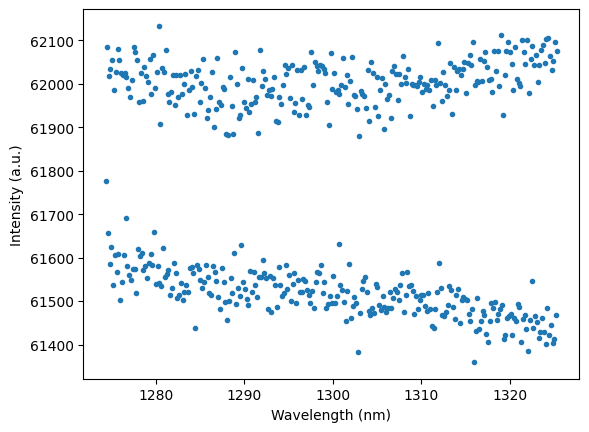

In [7]:

plt.plot(df_reference['Shamrock_calibration'], df_reference['Andor_spectrum_bg_subtracted'], ".")
plt.xlabel("Wavelength (nm)")
plt.ylabel("Intensity (a.u.)")
plt.show()

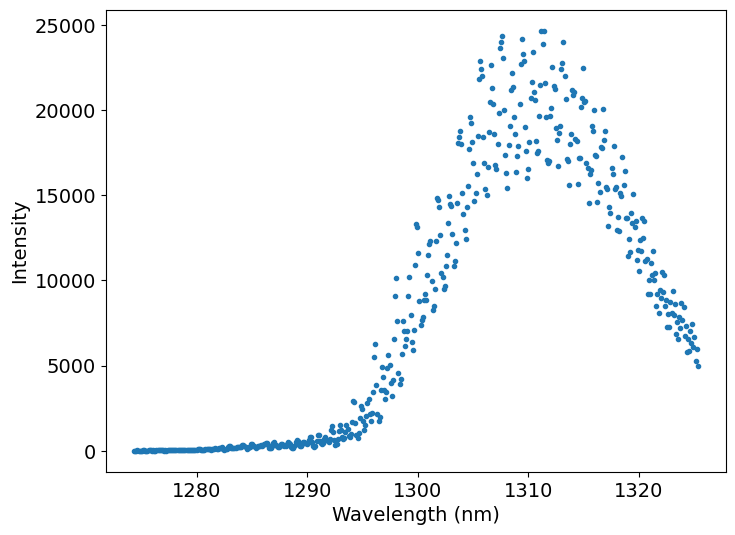

In [8]:
df_test = load_specfic_dataset(13)
df_test['Andor_spectrum_bg_subtracted'] = df_test['Andor_spectrum'] - df_background['Andor_spectrum']
plt.figure(figsize=(8,6))
plt.plot(df_test['Shamrock_calibration'], df_test['Andor_spectrum_bg_subtracted'], ".")
plt.xlabel("Wavelength (nm)", fontsize = 14)
plt.ylabel("Intensity", fontsize = 14)
plt.xticks(fontsize = 14)
plt.yticks(fontsize = 14)
plt.show()

In [9]:
#waveguide_losses_indices = np.arange(12, 20)
waveguide_losses_indices = np.array([13,14,16,17,18,19]) # Note 11 is the reference
print(waveguide_losses_indices)
wavelength_array = np.array([])
normalized_data = {}
poisson_uncertainties = {}
for number in waveguide_losses_indices:
    df_reset = load_specfic_dataset(number)
    df_reset['Andor_spectrum_bg_subtracted'] = df_reset['Andor_spectrum'] - df_background['Andor_spectrum']
    sqrt_array = np.sqrt(df_reset["Andor_spectrum"].values)

    poisson_uncertainties[number] = sqrt_array
    # Get the intensities for each wavelength and save them.

    normalized_intensity = df_reset['Andor_spectrum_bg_subtracted'] / df_reference['Andor_spectrum_bg_subtracted']

    #print(normalized_intensity)
    
    
    for wavelength, intensity in zip(df_reset['Shamrock_calibration'], normalized_intensity):
            if wavelength not in normalized_data:
                normalized_data[wavelength] = []
            normalized_data[wavelength].append(intensity)



[13 14 16 17 18 19]


In [10]:
# Perhaps use curvefit
def linear_func(a,x,b):
    return a*x + b

def exp_func(x, a, b, c):
    return a * np.exp(-b * x + c)


In [11]:
# Inserting the length of the waveguides, which follow the certain equation + turns! 

L_0 = 120
dL = 30
i = np.array([0,1,2,3,4,5])

L = L_0 + i * (2*dL) * 4
Turns = 12 * 3 

length_tot = (L + Turns)/ 1000 # /1000 to get mm

print(length_tot)

[0.156 0.396 0.636 0.876 1.116 1.356]


In [12]:
popt, pcov = curve_fit(linear_func, length_tot, 10*np.log10(normalized_data[1305.92639160156]), p0=[-6, -5]) # 1317.42724609375
print((popt))
print(pcov)

[-8.21966796 -4.56626593]
[[ 1.53923982 -1.16366531]
 [-1.16366531  1.13832327]]


-8.219667960664673


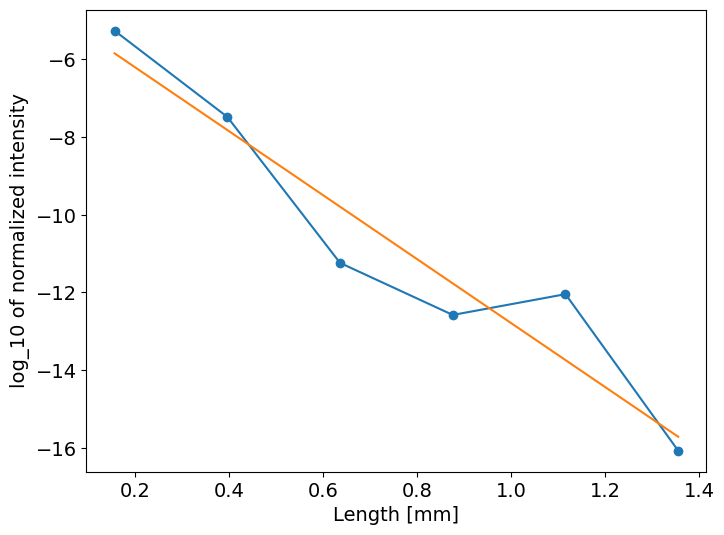

In [13]:
# Plotting the losses for a given wavelength

print(popt[0])
plt.figure(figsize=(8, 6))  # Increase figure size (width, height in inches)
#plt.plot(length_tot, intercept + slope * np.array(len_sup), 'r', label='Fitted line')
plt.plot(length_tot, 10*np.log10(normalized_data[1305.92639160156]), marker='o')
plt.plot(length_tot, linear_func(length_tot, *popt))
plt.xlabel("Length [mm]", fontsize = 14)
plt.ylabel("log_10 of normalized intensity", fontsize = 14)
#plt.title("Maximum Intensity vs Spiral Structure Index")
plt.xticks(fontsize = 14)
plt.yticks(fontsize = 14)
plt.show()

In [14]:
# Now we calculate the slope for each wavelength and plot that 

fit_results = {}


for wavelength, measurements in normalized_data.items():
    #print(type(wavelength))
    #print(type(measurements))
    y = np.array(measurements)

    # Filter out non-positive values for log
    mask = y > 0
    if np.sum(mask) < 2:  # Need at least 2 points
        continue
    
    x_filtered = length_tot[mask]
    y_filtered = 10*np.log10(y[mask])
    
    popt, pcov = curve_fit(linear_func, x_filtered, y_filtered, p0=[-4, -5])
    
    fit_results[wavelength] = {
        "params": popt,
        "covariance": pcov
    }

C:\Users\emile\AppData\Local\Temp\ipykernel_27240\2053660617.py:19: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(linear_func, x_filtered, y_filtered, p0=[-4, -5])


Some of the fit's be really bad because of a lack of data, so thereby it will be hard to estimate the covariance for those

In [15]:
fit_results[1275.15734863281]

{'params': array([ -1.06832131, -34.23544946]),
 'covariance': array([[ 0.39659854, -0.29982852],
        [-0.29982852,  0.29329899]])}

In [16]:
slope = []
wavelengths = []
for i in fit_results:
    #print(i)
    #print(fit_results[i]["params"][0])
    wavelengths.append(i)
    slope.append(fit_results[i]["params"][0]) 
wavelengths_arr = np.array(wavelengths)
slope_arr = np.array(slope)

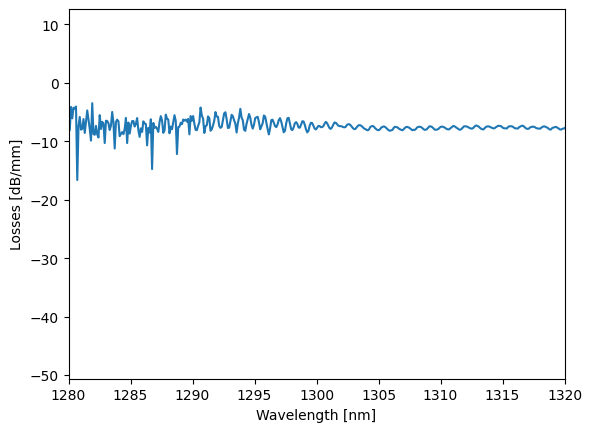

In [17]:
plt.plot(wavelengths, slope_arr)
plt.xlabel("Wavelength [nm]")
plt.ylabel("Losses [dB/mm]")
plt.xlim(1280, 1320)
#plt.ylim(-4,0)
plt.show()

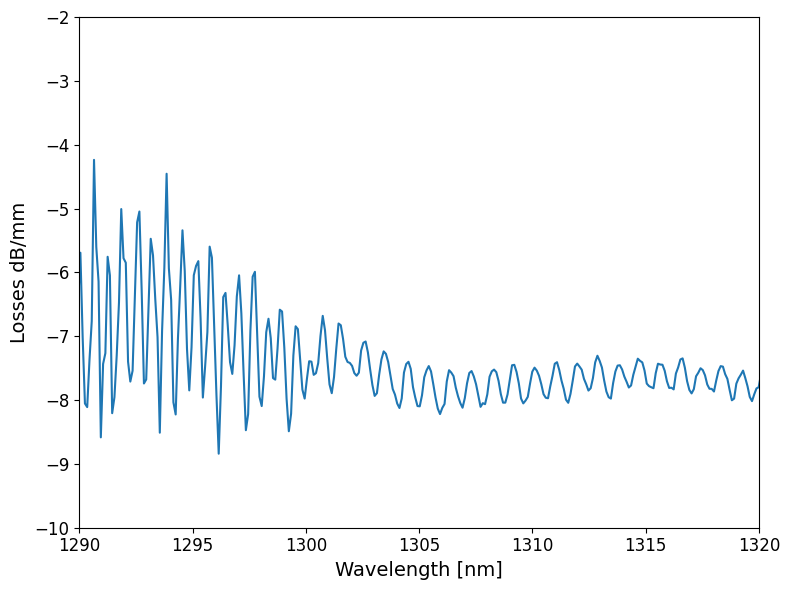

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6)) 
plt.plot(wavelengths, slope_arr)

plt.xlabel("Wavelength [nm]", fontsize=14)  
plt.ylabel("Losses dB/mm", fontsize=14)

plt.xticks(fontsize=12)  
plt.yticks(fontsize=12)  
plt.xlim(1290, 1320)
plt.ylim(-10, -2)
plt.tight_layout()  
plt.show()